# Project 2: Medical Route Optimization

This notebook demonstrates the Genetic Algorithm solution for the Vehicle Routing Problem (VRP) in a medical delivery context.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))
import random
from src.models.location import Location
from src.models.vehicle import Vehicle
from src.algorithms.genetic_optimizer import GeneticOptimizer
from src.utils.plotter import Plotter
from src.llm.report_generator import ReportGenerator
from src.utils.data_loader import DataLoader

/Users/rogeriobrumhermany/Projects/fiap/tsp/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# 1. Define Problem Data
depot = Location(0, 50, 50, "Central Depot", type='depot')

NUM_LOCATIONS = 60

locations = DataLoader.load_data(limit=NUM_LOCATIONS, data_dir='../data')

# Create Fleet
# Estimate required capacity
deliveries = [l for l in locations if getattr(l, 'type', 'delivery') == 'delivery']
total_demand = sum(l.demand for l in deliveries)
num_vehicles = 6

fleet = []
total_capacity = 0
total_distance = 0
for i in range(num_vehicles):
    capacity = random.randint(3, 6)
    total_capacity += capacity
    max_distance = random.randint(100, 200)
    total_distance += max_distance
    fleet.append(Vehicle(id=i+1, capacity=capacity, max_distance=max_distance))

print(f"Loaded {NUM_LOCATIONS} locations from dataset and {len(locations) - NUM_LOCATIONS} gas stations.")
print(f"Created Fleet of {len(fleet)} vehicles with total load capacity of {total_capacity} and total autonomy distance of {total_distance}")
print("Fleet: ")
for vehicle in fleet:
    print(f"Vehicle {vehicle.id} has a capacity of {vehicle.capacity} and a max distance of {vehicle.max_distance}")

Loaded 60 locations from dataset and 10 gas stations.
Created Fleet of 6 vehicles with total load capacity of 25 and total autonomy distance of 898
Fleet: 
Vehicle 1 has a capacity of 4 and a max distance of 150
Vehicle 2 has a capacity of 3 and a max distance of 137
Vehicle 3 has a capacity of 5 and a max distance of 189
Vehicle 4 has a capacity of 5 and a max distance of 139
Vehicle 5 has a capacity of 3 and a max distance of 151
Vehicle 6 has a capacity of 5 and a max distance of 132


In [3]:
# 2. Run Genetic Algorithm
locations_times_vehicles = NUM_LOCATIONS * num_vehicles
generations = locations_times_vehicles * 4 
population_size = 60
early_stopping_rounds = 50


optimizer = GeneticOptimizer(locations, depot, fleet, generations=generations, population_size=population_size, early_stopping_rounds=early_stopping_rounds, priority_weight=0.1)
best_routes, best_dist, fitness_history = optimizer.run()

print(f"Best Total Distance: {best_dist:.2f}")

Stopping early at generation 783 due to no improvement for 50 rounds.
Best Total Distance: 1673.99


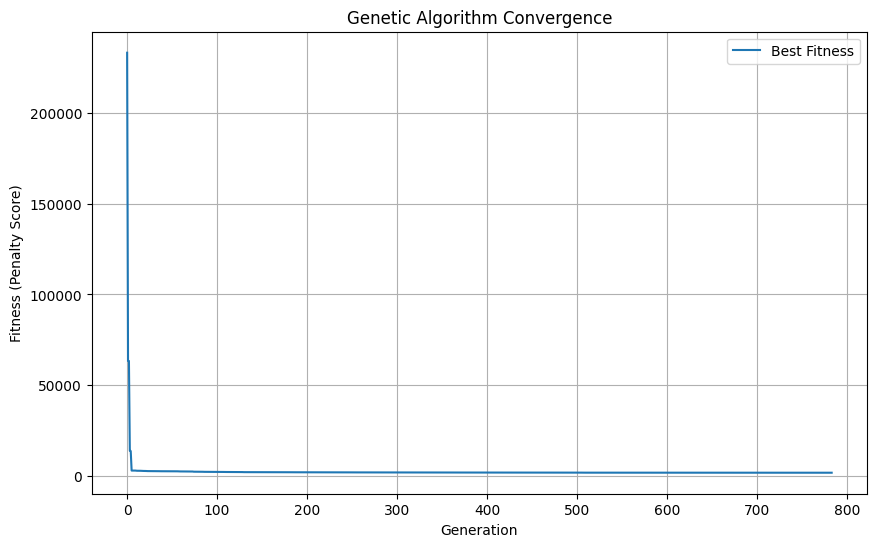

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(fitness_history, label='Best Fitness')
plt.title('Genetic Algorithm Convergence')
plt.xlabel('Generation')
plt.ylabel('Fitness (Penalty Score)')
plt.grid(True)
plt.legend()
plt.show()

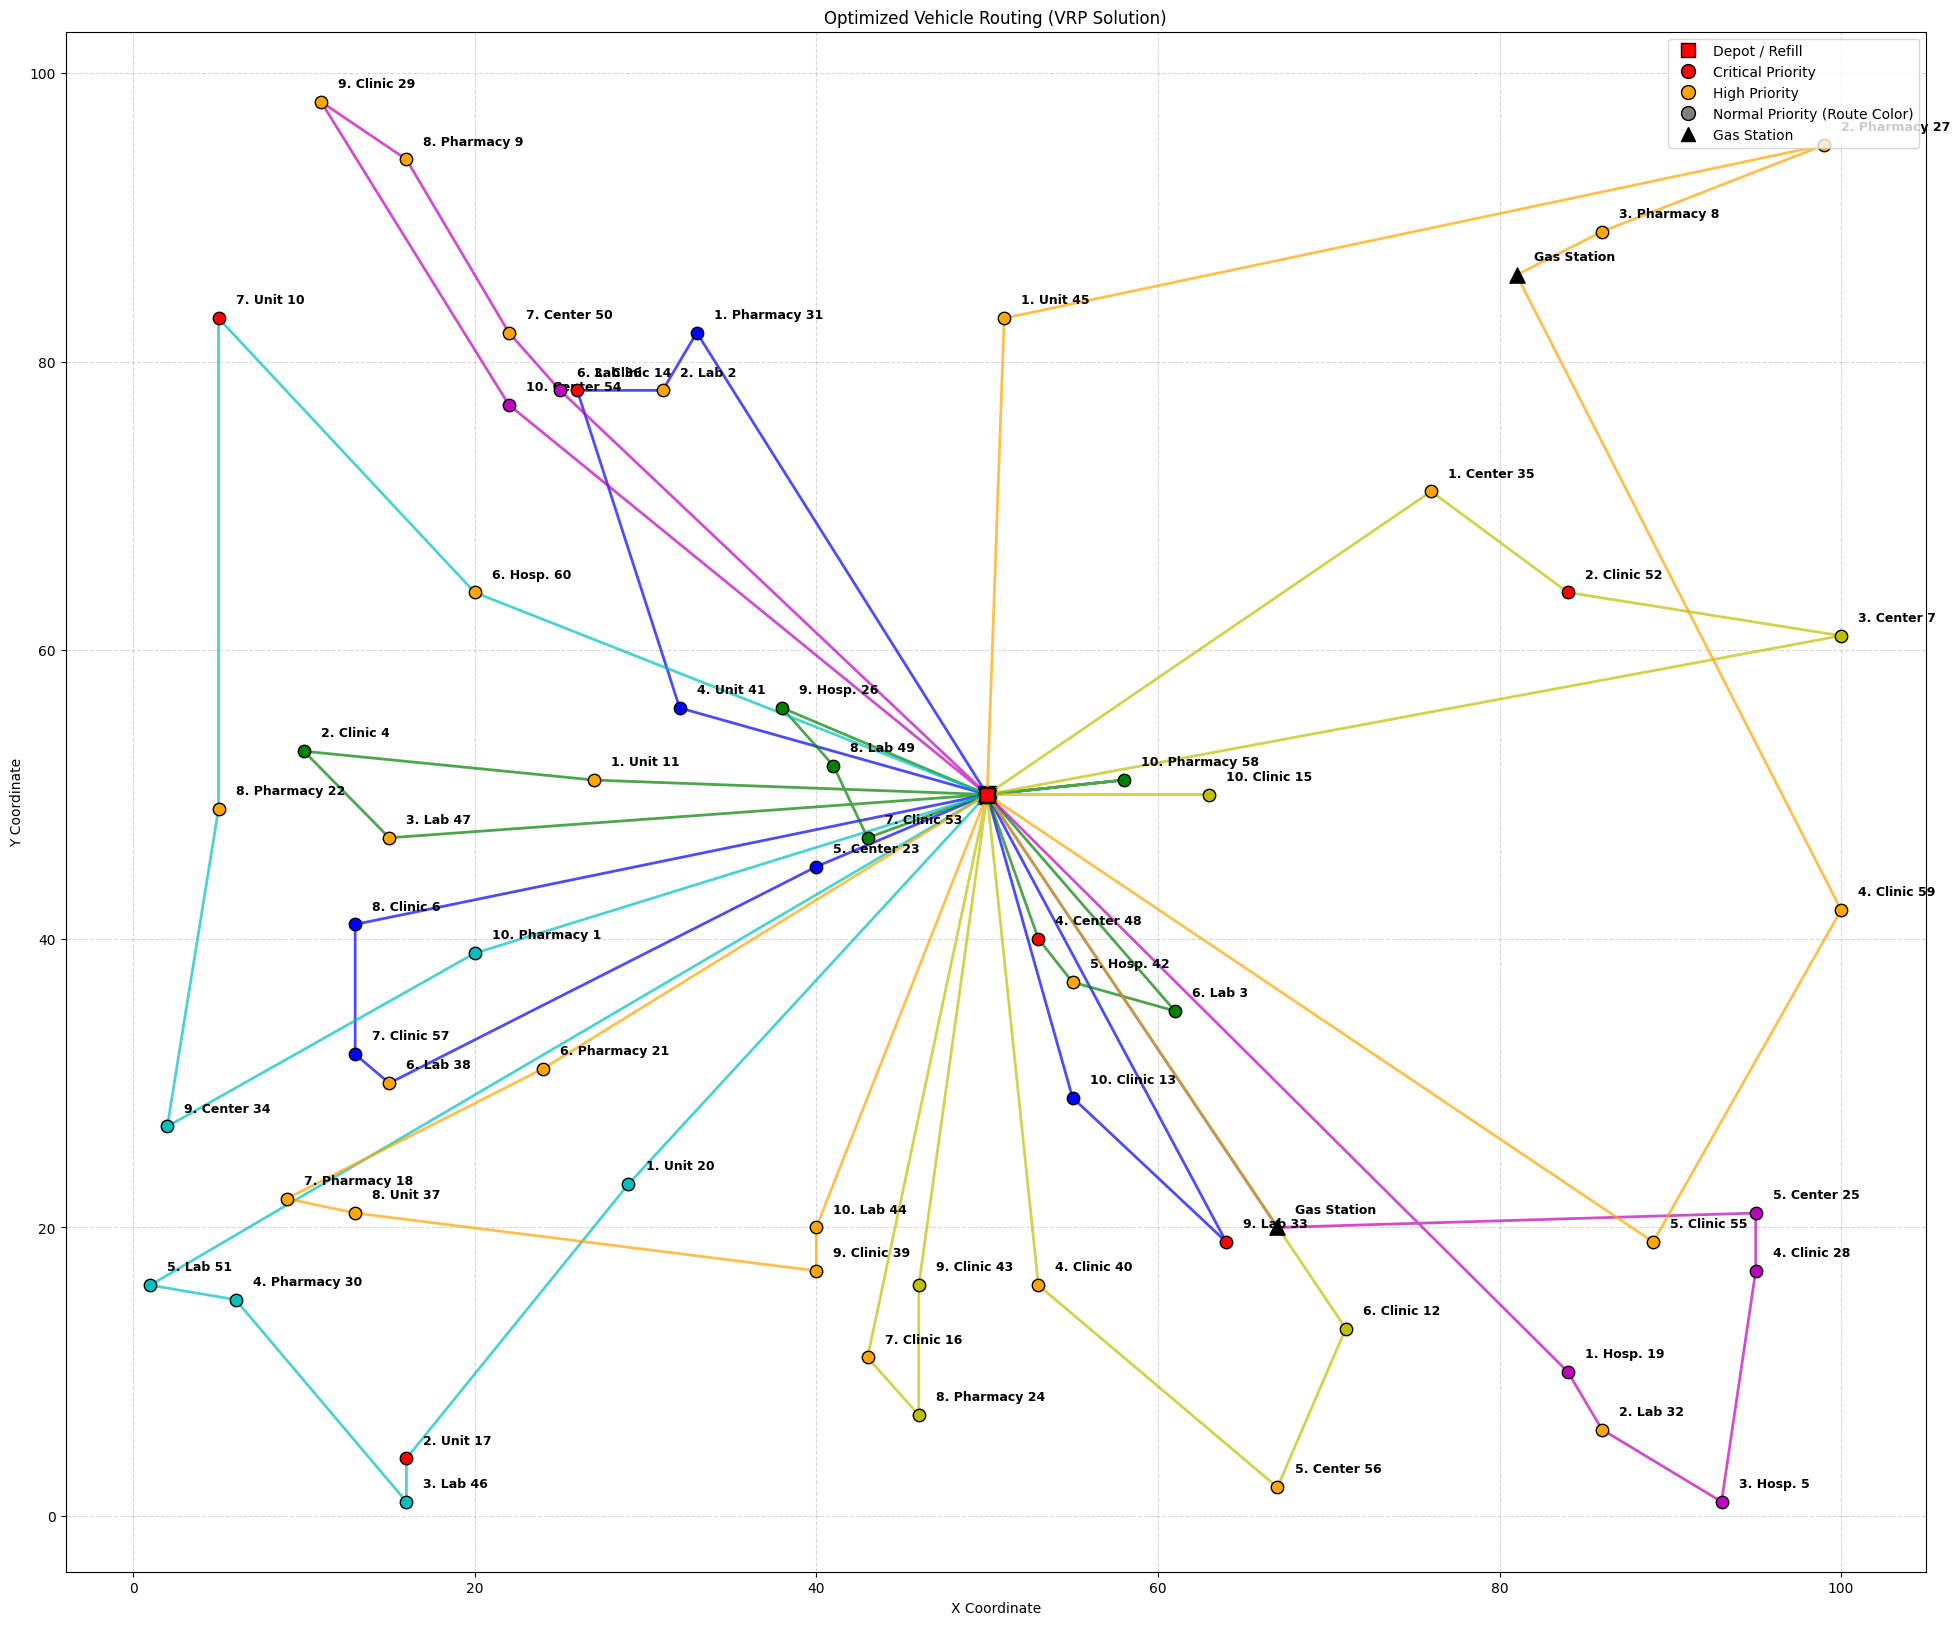

In [5]:
# 3. Visualize Solution
Plotter.plot_solution(best_routes, depot)

In [6]:
# 4. Generate LLM Report
llm = ReportGenerator()

print("Generating Instructions for Drivers...\n")

max_reports = 3

for i, route in enumerate(best_routes[:max_reports]):
    print(llm.generate_driver_instructions(i, route))
    print("\n" + "="*40 + "\n")

if len(best_routes) > max_reports:
    print(f"... and {len(best_routes) - max_reports} more routes.")

Loading local model: Qwen/Qwen2.5-3B-Instruct...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Device set to use mps


Model loaded successfully.
Generating Instructions for Drivers...

Hey there,

Good day out there! Here's what we've got:

- Pharmacy 31 (Normal Priority)
- Lab 2 (Immediate Priority)
- Clinic 14 (High Priority)
- Unit 41 (Normal Priority)

Then we're headed to the Central Depot:
- Center 23 (Normal Priority)
- Lab 38 (Immediate Priority)
- Clinic 57 & 6 (Normal Priority)
- Lab 33 (High Priority)
- Clinic 13 (Normal Priority)

Safety first, keep your eyes on the road!

Out!


Hey there! 

Starting off the day:

- At Unit 11 - Get there ASAP!
- Head to Clinic 4 - Normal priority
- Then Lab 47 - Get this one quick!

Then, Central Depot:

- Center 48 - This is a high priority stop
- Hosp. 42 - You gotta get there FAST!
- Lab 3 - Normal priority

Last stops at Central Depot:

- Clinic 53 - Normal priority
- Lab 49 - Normal priority
- Hosp. 26 - Normal priority

And finally:

- Pharmacy 58 - Normal priority

Remember, safety first. Safe travels!


Hey there,

Good day out there! Here's what